# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [3]:
from typing import Tuple

from matplotlib.figure import Figure
from pandas import DataFrame
from torch.distributions.constraints import dependent

from mlp.penalties import L1Penalty, L2Penalty, L1L2MixPenalty

ROOT = "/Users/matthewgiles/PycharmProjects/mlpractical"
FIGURE_PATH = f"{ROOT}/report/figures"

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
import sys
sys.path.append(ROOT)

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [8]:
import os

# Set all the env variables
os.environ["MLP_DATA_DIR"] = os.path.join(ROOT, "data")

In [45]:


from mlp.layers import DropoutLayer


class CustomModel(MultipleLayerModel):
    
    def __init__(self, 
                input_dim=784, 
                output_dim=47,
                width=128,
                depth=2,
                reg=None, 
                coefficient=0.5, 
                coefficient2=0.5,
                rng=None,
                activation=None,
             ):
        
        # Set the model parameters
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.width = width
        self.depth = depth
        self.reg = reg
        self.coefficient = coefficient
        self.coefficient2 = coefficient2
        self.rng = rng
        
        # Weight initializers    
        self.weights_init = GlorotUniformInit(rng=self.rng)
        self.biases_init = ConstantInit(0.)
        
        self.penalty = None
        self.activation = activation
        
        if self.activation is None:
            self.activation = ReluLayer()
        
        # Ensure reg is lowercase for comparison
        if self.reg is not None:
            self.reg = self.reg.lower()
                
        if reg == "l1":
            self.penalty = L1Penalty(coefficient=self.coefficient)
        elif reg == "l2":
            self.penalty = L2Penalty(coefficient=self.coefficient)
        elif reg == "l1l2":
            self.penalty = L1L2MixPenalty(self.coefficient, self.coefficient2)
        
        # Build the model
        self.build()
        self.compile()
    
    def build(self):
        
        # Init the layers
        # Hidden layer 1
        layers = [
            AffineLayer(self.input_dim, self.width, self.weights_init, self.biases_init),
            self.activation,
        ]
        
        for _ in range(self.depth-1):
            print("Adding hidden layer", _)
            layers.append(AffineLayer(
                self.width, self.width, self.weights_init, self.biases_init, weights_penalty=self.penalty, biases_penalty=None,
            ))
            layers.append(self.activation)
            
            if self.reg == "dropout":
                layers.append(DropoutLayer(incl_prob=self.coefficient))
        
        # Add the output layer
        layers.append(AffineLayer(
            self.width, self.output_dim, self.weights_init, self.biases_init,
            weights_penalty=self.penalty, biases_penalty=None,
        ))
        
        return super().__init__(layers)
    
    def compile(self, learning_rate=0.001):
        self.error = CrossEntropySoftmaxError()
        self.learning_rule = AdamLearningRule(learning_rate=learning_rate)
        
    def fit(self, train_data, valid_data, num_epochs=5, stats_interval=1, notebook=True, gradients=False):

        # Return a pandas dataframe with all the info we are interested in
        optimiser = Optimiser(
            self, 
            self.error, 
            self.learning_rule, 
            train_data,
            valid_data,
            data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}, 
            notebook=notebook
        )
        
        # Train the model
        stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)
        
        # Get the info
        # Set the columns to the keys of info + keys
        out_df = pd.DataFrame(columns=list(self.info.keys()) + ["epoch"] + list(keys.keys()))
        
        for e in range(num_epochs):
            
            # Copy the info
            info = self.info.copy()
            info["epoch"] = e + 1
            
            # Loop through the keys and add all their info
            for key in keys:
                info[key] = stats[e, keys[key]]
                
            # Add to the dataframe
            # AttributeError: 'DataFrame' object has no attribute 'append' 
            # out_df = out_df.append(info, ignore_index=True)
            out_df = pd.concat([out_df, pd.DataFrame([info])], ignore_index=True)

        # Order by the epoch
        out_df = out_df.sort_values(by=["epoch"])
                
        # Get the gradient plot
        if gradients:
            
            # Plot the gradient flow
            grad_plot, grad_ax = optimiser.plot_grad_flow()
            
            return out_df, grad_plot
        else:
            return out_df
    
    @property
    def info(self):
        return {
            "input_dim": self.input_dim,
            "output_dim": self.output_dim,
            "width": self.width,
            "depth": self.depth,
            "reg": self.reg,
            "coefficient": self.coefficient,
            "coefficient2": self.coefficient2,
        }


In [90]:

class Plotter:
    

    # def get_independent(self):
    #     
    #     # Ignore the dependent variables
    #     dependent_vars = ["epoch", "acc(train)", "acc(valid)", "error(train)", "error(valid)"]
    #     
    #     q2_df.nunique()
    #     
    #     for key, value in self.df.nunique().items():
    #         
    #         if key in dependent_vars:
    #             continue
    #             
    #         if value > 1:
    #             return key
        
    @staticmethod
    def plot(df, name=None):
        
        # Plot the error and accuracy against the independent variable
        metrics = ["acc", "error"]
        names = ["Accuracy", "Error"]
        
        
        for metric, metric_name in zip(metrics, names):
            plt.figure(figsize=(8, 4))
            
            for ind_key in df[name].unique():
                
                # Plot across the epochs for the independent variable
                sub_df = df[df[name] == ind_key]
                
                datasets = ["train", "valid"]
                line_style = ["-", "--"]
                
                for ds, style in zip(datasets, line_style):
                    plt.plot(
                        sub_df["epoch"],
                        sub_df[f"{metric}({ds})"],
                        linestyle=style,
                        label=f"{name} {ind_key}({ds})"
                    )
        
            plt.xlabel("Epoch number")
            plt.ylabel(metric_name)
            plt.title(f"{metric_name} vs {name}")
            plt.legend(loc="best")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            
            # Get the name 
            if name is None:
                name = f"curve_{name}"
                
            # The path we are saving
            path = os.path.join(FIGURE_PATH, f"{name}_{metric}.png")
            
            print("Saving figure to:", path)
            
            # Save the name of the figure
            plt.savefig(path, bbox_inches="tight")
            
            
    @staticmethod
    def print_latex_rows(df, cols=None):
        
        all_cols = cols + ["acc(valid)", "error(train)", "error(valid)"]
        
        # Get the final epoch
        final_epoch = df["epoch"].max()
        final_df = df[df["epoch"] == final_epoch]
        
        # Sort by the indepdent variable
        final_df = final_df.sort_values(by=cols)
        
        # indepdent var & Val. Acc. & Train Error & Val. Error\\
        for _, row in final_df.iterrows():
            line = ""
            for i, col in enumerate(all_cols):
                if i == 0:
                    line += "& "
                else:
                    line += f"{row[col]:>7.3f}   "
            line += "\\\\"
            print(line)
        

In [47]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100

# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

smooth_train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=True)
smooth_valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=True)

KeysView(<numpy.lib.npyio.NpzFile object at 0x138d34520>)
KeysView(<numpy.lib.npyio.NpzFile object at 0x138d31b40>)
KeysView(<numpy.lib.npyio.NpzFile object at 0x138d05540>)
KeysView(<numpy.lib.npyio.NpzFile object at 0x138d07070>)


# Question 2:

In [85]:
widths = [128, 64, 32]

# The joined df
q2_df = pd.DataFrame()

for width in widths:
    
    # Build the model with the width
    model = CustomModel(
        width=width
    )
    model.compile(learning_rate=9e-4)
    
    # Train to get the info
    df = model.fit(
        train_data,
        valid_data,
    )
    
    print("len(df):", len(df))
    print("len(q2_df) 1:", len(q2_df))
    
    # Add to the df
    q2_df = pd.concat([q2_df, df], ignore_index=True)
    
    print("len(q2_df) 2:", len(q2_df))
    

Adding hidden layer 0


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 5.6s to complete
    error(train)=7.89e-01, acc(train)=7.60e-01, error(valid)=8.10e-01, acc(valid)=7.50e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 4: 2.2s to complete
    error(train)=8.91e-01, acc(train)=7.37e-01, error(valid)=9.14e-01, acc(valid)=7.30e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 1.6s to complete
    error(train)=8.34e-01, acc(train)=7.52e-01, error(valid)=8.62e-01, acc(valid)=7.43e-01


len(df): 5
len(q2_df) 1: 10
len(q2_df) 2: 15


/var/folders/p3/gzg9876x5cdf6httpsjkn3940000gn/T/ipykernel_21340/900533194.py:112: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out_df = pd.concat([out_df, pd.DataFrame([info])], ignore_index=True)


In [92]:
# Plot the values
Plotter.plot(q2_df)
Plotter.print_latex_rows(q2_df, cols=["width"])

KeyError: None

<Figure size 800x400 with 0 Axes>

# Question 3:

In [87]:
depths = [1, 2, 3]

# The joined df
q3_df = pd.DataFrame()

for depth in depths:
    
    # Build the model with the width
    model = CustomModel(
        depth=depth,
    )
    model.compile(learning_rate=9e-4)
    
    # Train to get the info
    df = model.fit(
        train_data,
        valid_data,
    )
    
    # Add to the df
    q3_df = pd.concat([q3_df, df], ignore_index=True)
    

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 4.8s to complete
    error(train)=9.48e-01, acc(train)=7.25e-01, error(valid)=9.62e-01, acc(valid)=7.22e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 4.0s to complete
    error(train)=7.41e-01, acc(train)=7.75e-01, error(valid)=7.72e-01, acc(valid)=7.66e-01


...

Epoch 3: 4.2s to complete
    error(train)=4.92e-01, acc(train)=8.34e-01, error(valid)=5.57e-01, acc(valid)=8.15e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 6.2s to complete
    error(train)=4.40e-01, acc(train)=8.49e-01, error(valid)=5.15e-01, acc(valid)=8.30e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 5.8s to complete
    error(train)=4.26e-01, acc(train)=8.50e-01, error(valid)=5.17e-01, acc(valid)=8.26e-01
/var/folders/p3/gzg9876x5cdf6httpsjkn3940000gn/T/ipykernel_21340/900533194.py:112: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out_df = pd.concat([out_df, pd.DataFrame([info])], ignore_index=True)


In [93]:
# Plot the values
Plotter.plot(q3_df)
Plotter.print_latex_rows(q3_df, cols=["depth"])

KeyError: None

<Figure size 800x400 with 0 Axes>

# Question 4:

In [ ]:
import pandas as pd

regs = {
    "baseline": [""],
    "dropout": [0.6, 0.7, 0.85, 0.97],
    "l1": [5e-4, 1e-3, 5e-3, 5e-2],
    "l2": [5e-4, 1e-3, 5e-3, 5e-2],
    # "dropout": [0.35, 0.55, 0.75, 0.95],
    # "l1": [1e-13, 1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    # "l2": [1e-13, 1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    "smooth": [""],
}


q4_df = pd.DataFrame()

for reg, params in regs.items():
    
    for param in params:
        
        model = CustomModel(
            reg=reg,
            coefficient=param,
        )
        model.compile(learning_rate=1e-4)
        
        # Whether we are training on smooth
        smooth = (reg == "smooth")
        
        # Train on the data
        df = model.fit(
            smooth_train_data if smooth else train_data,
            smooth_valid_data if smooth else valid_data
        )
        
        # Add to the df
        q4_df = pd.concat([q4_df, df], ignore_index=True)
        

In [ ]:

# Loop through the different regs
for reg in regs.keys():
    
    # Get the sub df
    sub_df = q4_df[q4_df["reg"] == reg]
    
    print(f"--- LaTeX rows for {reg} ---")
    Plotter.print_latex_rows(sub_df, cols=["coefficient"])
    print("\n")


# Question 5:

In [ ]:

l1s = [1e-11, 1e-9]
l2s = [1e-11, 1e-9]

q5_df = pd.DataFrame()

for l1 in l1s:
    for l2 in l2s:
        
        # Build the custom model
        model = CustomModel(
            reg="l1l2",
            coefficient=l1,
            coefficient2=l2,
        )
        model.compile(learning_rate=1e-4)
        
        # Train on the data
        df = model.fit(
            train_data,
            valid_data
        )    
        
        # Add to the df
        q5_df = pd.concat([q5_df, df], ignore_index=True)


In [ ]:
Plotter.print_latex_rows(q5_df, cols=["coefficient", "coefficient2"])

# Question 6:

In [ ]:
# Build the custom model
model = CustomModel(
    activation=CustomActivationLayer(),
)
model.compile(learning_rate=1e-4)

# Train on the data
q6_df, grad_plot = model.fit(
    train_data,
    valid_data,
    gradients=True
)



In [ ]:
# Plot the info
Plotter.plot(q6_df, name="custom_activation")


In [ ]:
raise Exception("Stop here")

In [ ]:

l1l2_params = [(1e-11, 1e-11), (1e-9, 1e-9), (1e-9, 1e-11), (1e-11, 1e-9)]

# Generate a pandas dataframe
l1l2df = pd.DataFrame(
    columns=[
        "l1_coeff",
        "l2_coeff",
        "epoch",
        "train_acc",
        "train_err",
        "valid_acc",
        "valid_err",
        "gen_gap",
    ]
)


for (l1_coeff, l2_coeff) in l1l2_params:
    print(f"Training model with L1 coeff={l1_coeff}, L2 coeff={l2_coeff}")
    model = build_regularised_model(reg="l1l2", coefficient=l1_coeff, coefficient2=l2_coeff)

    # Train
    stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True
    )
    
    # Loop through the stats and add them to the plot
    for epoch in range(num_epochs):

        # Extract metrics
        final_train_acc = stats[epoch, keys["acc(train)"]]
        final_train_err = stats[epoch, keys["error(train)"]]
        final_valid_acc = stats[epoch, keys["acc(valid)"]]
        final_valid_err = stats[epoch, keys["error(valid)"]]
        final_gen_gap = final_valid_err - final_train_err

        # Append result
        df.loc[len(df)] = [
            l1_coeff,
            l2_coeff,
            epoch + 1,
            final_train_acc,
            final_train_err,
            final_valid_acc,
            final_valid_err,
            final_gen_gap,
        ]

In [25]:

def plot_width_accuracy_from_pack(records, epoch_start: int=1, save_path=None, show=True, prefix="width"):
    
    if not records:
        raise ValueError("No data provided.")

    # Use same style as your training plots
    plt.style.use("ggplot")

    # Sort for consistency
    records_sorted = sorted(records, key=lambda t: t[0])
    n_epochs = records_sorted[0][1].shape[0]
    epochs = np.arange(epoch_start, epoch_start + n_epochs)

    # --- Accuracy plot ---
    fig_acc = plt.figure(figsize=(8, 4))
    ax_acc = fig_acc.add_subplot(111)
    for w, arr, idx in records_sorted:
        ax_acc.plot(epochs, arr[:, idx["acc(train)"]], "-", label=f"{prefix} {w}(train)")
        ax_acc.plot(epochs, arr[:, idx["acc(valid)"]], "--", label=f"{prefix} {w}(valid)")
    ax_acc.set_xlabel("Epoch number")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend(loc="best")
    fig_acc.tight_layout()

    fig_err = plt.figure(figsize=(8, 4))
    ax_err = fig_err.add_subplot(111)
    for w, arr, idx in records_sorted:
        ax_err.plot(epochs, arr[:, idx["error(train)"]], "-", label=f"{prefix} {w}(train)")
        ax_err.plot(epochs, arr[:, idx["error(valid)"]], "--", label=f"{prefix} {w}(valid)")
    ax_err.set_xlabel("Epoch number")
    ax_err.set_ylabel("Error")
    ax_err.legend(loc="best")
    fig_err.tight_layout()

    if save_path:
        fig_acc.savefig(os.path.join(FIGURE_PATH, f"acc_{save_path}.png"), bbox_inches="tight")
        fig_err.savefig(os.path.join(FIGURE_PATH, f"error_{save_path}.png"), bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig_acc)
        plt.close(fig_err)


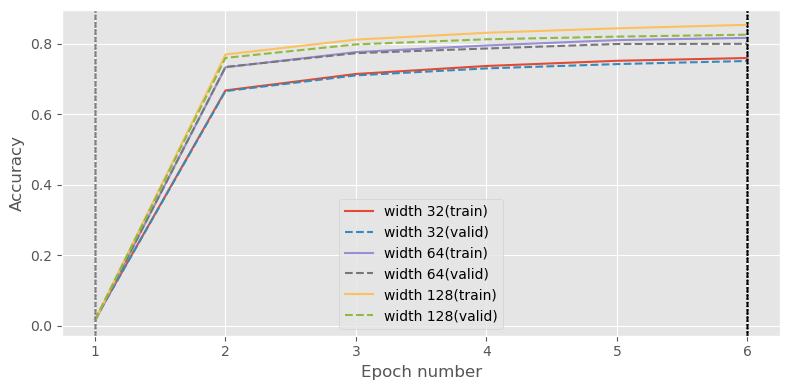

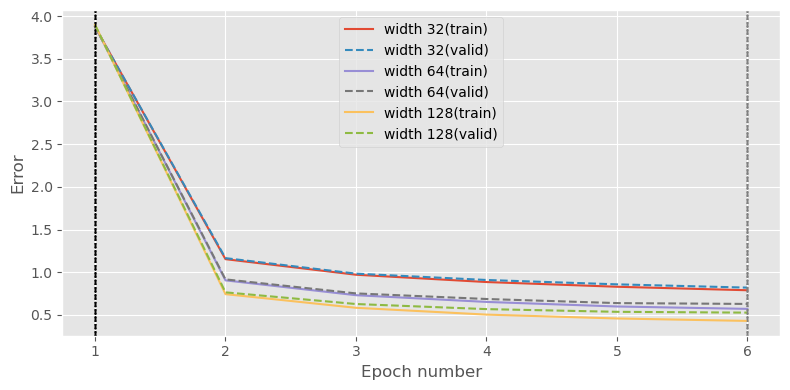


Extrema summary:
width 32 | acc(train): min=0.0181 at epoch 1, max=0.7594 at epoch 6
width 32 | acc(valid): min=0.0173 at epoch 1, max=0.7509 at epoch 6
width 64 | acc(train): min=0.0140 at epoch 1, max=0.8165 at epoch 6
width 64 | acc(valid): min=0.0135 at epoch 1, max=0.7997 at epoch 6
width 128 | acc(train): min=0.0156 at epoch 1, max=0.8536 at epoch 6
width 128 | acc(valid): min=0.0165 at epoch 1, max=0.8256 at epoch 6
width 32 | error(train): min=0.7895 at epoch 6, max=3.8745 at epoch 1
width 32 | error(valid): min=0.8204 at epoch 6, max=3.8727 at epoch 1
width 64 | error(train): min=0.5715 at epoch 6, max=3.8807 at epoch 1
width 64 | error(valid): min=0.6293 at epoch 6, max=3.8832 at epoch 1
width 128 | error(train): min=0.4305 at epoch 6, max=3.8975 at epoch 1
width 128 | error(valid): min=0.5275 at epoch 6, max=3.8972 at epoch 1


In [26]:
# Your data pasted into a variable named `packed`
plot_width_accuracy_from_pack(output_stats, save_path=f"acc_curve_width.png")

In [ ]:
def build_depth_model(depth=1):
    input_dim, output_dim, hidden_dim = 784, 47, 128
        
        
    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)

    
    layers = [
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
        ReluLayer(),
    ]
    
    for _ in range(depth):
        layers.append(AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init))
        layers.append(ReluLayer())
    
    # Add the output layer
    layers.append(AffineLayer(hidden_dim, output_dim, weights_init, biases_init))
    
    return MultipleLayerModel(layers)

In [ ]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1


error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

depth = [1, 2, 3]

output_stats_depth = []

for d in depth:
    print(f"Training model with depth={d}")
    model = build_depth_model(depth=d)

    # Remember to use notebook=False when you write a script to be run in a terminal
    stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

    output_stats_depth.append((d, stats, keys))


In [ ]:
print_latex_rows(output_stats_depth)

In [ ]:
plot_width_accuracy_from_pack(output_stats_depth, save_path=f"curve_depth", prefix="depth")

In [ ]:
def build_regularised_model(reg="dropout", coefficient=0.5, coefficient2=0.5):
    
    depth = 3
    input_dim, output_dim, hidden_dim = 784, 47, 128
        
        
    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)
    
    penalty = None
    
    # Ensure reg is lowercase for comparison
    reg = reg.lower()
    
    if reg == "l1":
        penalty = L1Penalty(coefficient=coefficient)
    elif reg == "l2":
        penalty = L2Penalty(coefficient=coefficient)
    elif reg == "l1l2":
        penalty = L1L2MixPenalty(coefficient, coefficient2)
        
    layers = [
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
        ReluLayer(),
    ]
    
    for _ in range(depth):
        print("Adding hidden layer", _)
        layers.append(AffineLayer(
            hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=penalty, biases_penalty=None,
        ))
        layers.append(ReluLayer())
        
        if reg == "dropout":
            layers.append(DropoutLayer(incl_prob=coefficient))
    
    # Add the output layer
    layers.append(AffineLayer(
        hidden_dim, output_dim, weights_init, biases_init,
        weights_penalty=penalty, biases_penalty=None,
    ))
    
    return MultipleLayerModel(layers)

Training model with smooth param=
Adding hidden layer 0
Adding hidden layer 1
Adding hidden layer 2


Ep Prog: 100%|██████████| 1000/1000 [00:22<00:00, 43.94it/s][A
Epoch 1: 22.8s to complete
    error(train)=1.86e+00, acc(train)=6.41e-01, error(valid)=1.86e+00, acc(valid)=6.40e-01
Ep Prog: 100%|██████████| 1000/1000 [00:18<00:00, 53.32it/s][A
Epoch 2: 18.8s to complete
    error(train)=1.67e+00, acc(train)=6.99e-01, error(valid)=1.68e+00, acc(valid)=6.97e-01
Ep Prog: 100%|██████████| 1000/1000 [00:18<00:00, 54.03it/s]
Epoch 3: 18.5s to complete
    error(train)=1.55e+00, acc(train)=7.39e-01, error(valid)=1.56e+00, acc(valid)=7.34e-01
Ep Prog: 100%|██████████| 1000/1000 [00:23<00:00, 42.44it/s][A
Epoch 4: 23.6s to complete
    error(train)=1.48e+00, acc(train)=7.62e-01, error(valid)=1.49e+00, acc(valid)=7.56e-01
Ep Prog: 100%|██████████| 1000/1000 [00:21<00:00, 46.05it/s][A
Epoch 5: 21.7s to complete
    error(train)=1.42e+00, acc(train)=7.80e-01, error(valid)=1.44e+00, acc(valid)=7.73e-01
Exp Prog: 100%|██████████| 5/5 [01:58<00:00, 23.61s/it]

  regularisation parameter  train_acc  train_err  valid_acc  valid_err  \
0         smooth              0.78036   1.423416   0.772911   1.439879   

    gen_gap  
0  0.016463  


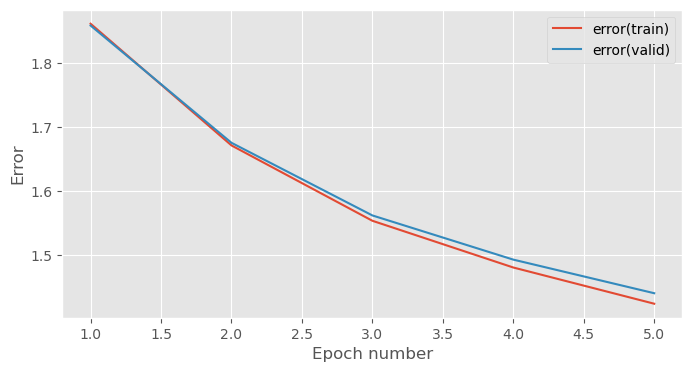

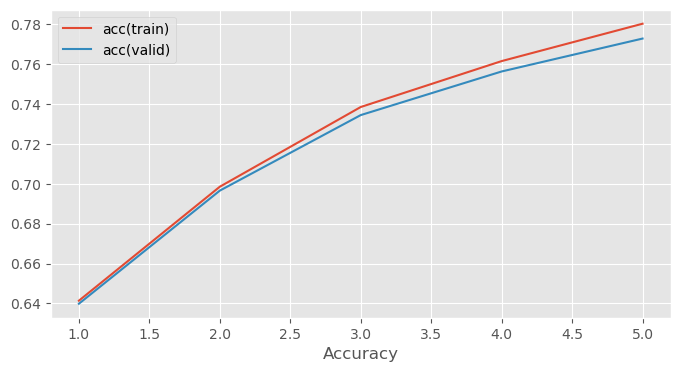

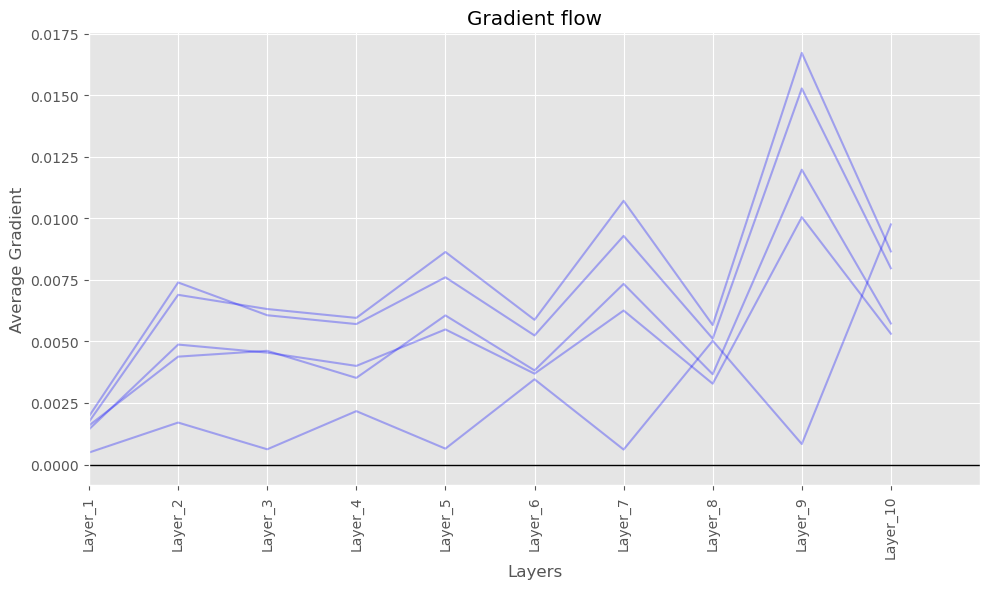

In [126]:
import pandas as pd

# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 5
stats_interval = 1

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)

regs = {
    # "baseline": [""],
    # "dropout": [0.6, 0.7, 0.85, 0.97],
    # "dropout": [0.35, 0.55, 0.75, 0.95],#, 0.75, 0.85, 0.97],
    # "l1": [1e-13, 1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    # "l2": [1e-13, 1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
    "smooth": [""],
}

df_params = pd.DataFrame(
    columns=[
        "regularisation",
        "parameter",
        "train_acc",
        "train_err",
        "valid_acc",
        "valid_err",
        "gen_gap",
    ]
)

# Single loop: train + record results
for reg, params in regs.items():
    for param in params:
        print(f"Training model with {reg} param={param}")
        model = build_regularised_model(reg=reg, coefficient=param)

        # Select data
        if reg == "smooth":
            t_data, v_data = smooth_train_data, smooth_valid_data
        else:
            t_data, v_data = train_data, valid_data

        # Train
        stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
            model, error, learning_rule, t_data, v_data, num_epochs, stats_interval, notebook=False
        )
        
        # Extract metrics
        final_train_acc = stats[-1, keys["acc(train)"]]
        final_train_err = stats[-1, keys["error(train)"]]
        final_valid_acc = stats[-1, keys["acc(valid)"]]
        final_valid_err = stats[-1, keys["error(valid)"]]
        final_gen_gap = final_valid_err - final_train_err

        # Append result
        df.loc[len(df)] = [
            reg,
            param,
            final_train_acc,
            final_train_err,
            final_valid_acc,
            final_valid_err,
            final_gen_gap,
        ]

# View all results
print(df)


In [133]:
def print_latex_rows_params(df, acc_decimals: int = 3, err_decimals: int = 3, start_with_and: bool = False):
    # Group by regularisation
    df_grouped = df.groupby("regularisation")
    
    print("df_grouped:", df_grouped.head())

    # Loop through each group
    for reg, group in df_grouped:
        # Find best row (highest valid_acc, or lowest valid_err if tie)
        best_idx = group["valid_acc"].idxmax()
        best_row = df.loc[best_idx]

        # Round metrics
        t_acc = round(best_row["train_acc"], acc_decimals)
        v_acc = round(best_row["valid_acc"], acc_decimals)
        t_err = round(best_row["train_err"], err_decimals)
        v_err = round(best_row["valid_err"], err_decimals)
        g_gap = round(best_row["gen_gap"], err_decimals)

        # Format prefix
        prefix = "& " if start_with_and else ""
        
        # Print LaTeX row
        print(
            f"{prefix}{reg} & {best_row['parameter']} & {t_acc} & {t_err} & {v_acc} & {v_err} & {g_gap} \\\\"
        )


In [134]:
print_latex_rows_params(df_params)

df_grouped: Empty DataFrame
Columns: [regularisation, parameter, train_acc, train_err, valid_acc, valid_err, gen_gap]
Index: []


In [ ]:


# For each regularisation type output the results in LaTeX format
for reg in regs.keys():
    sub_df = df[df["regularisation"] == reg]
    print_latex_rows2(sub_df)


In [ ]:

# --- L1/L2 plot ---
l1l2_df = df[df["regularisation"].isin(["l1", "l2"])]

plt.figure(figsize=(6, 4))
for reg in ["l1", "l2"]:
    sub_df = l1l2_df[l1l2_df["regularisation"] == reg]
    plt.plot(sub_df["parameter"], sub_df["valid_acc"], marker="o", label=f"{reg.upper()} Validation Accuracy")
    plt.plot(sub_df["parameter"], sub_df["gen_gap"], marker="s", label=f"{reg.upper()} Gen Gap")

plt.xscale("log")
plt.xlabel("Weight Penalty (log scale)")
plt.ylabel("Metric Value")
plt.title("Accuracy and Error by Weight Penalty")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f"wd_plot.png"), dpi=300)
plt.close()

In [ ]:

l1l2_params = [(1e-11, 1e-11), (1e-9, 1e-9), (1e-9, 1e-11), (1e-11, 1e-9)]

# Generate a pandas dataframe
l1l2df = pd.DataFrame(
    columns=[
        "l1_coeff",
        "l2_coeff",
        "epoch",
        "train_acc",
        "train_err",
        "valid_acc",
        "valid_err",
        "gen_gap",
    ]
)


for (l1_coeff, l2_coeff) in l1l2_params:
    print(f"Training model with L1 coeff={l1_coeff}, L2 coeff={l2_coeff}")
    model = build_regularised_model(reg="l1l2", coefficient=l1_coeff, coefficient2=l2_coeff)

    # Train
    stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True
    )
    
    # Loop through the stats and add them to the plot
    for epoch in range(num_epochs):

        # Extract metrics
        final_train_acc = stats[epoch, keys["acc(train)"]]
        final_train_err = stats[epoch, keys["error(train)"]]
        final_valid_acc = stats[epoch, keys["acc(valid)"]]
        final_valid_err = stats[epoch, keys["error(valid)"]]
        final_gen_gap = final_valid_err - final_train_err

        # Append result
        df.loc[len(df)] = [
            l1_coeff,
            l2_coeff,
            epoch + 1,
            final_train_acc,
            final_train_err,
            final_valid_acc,
            final_valid_err,
            final_gen_gap,
        ]

In [ ]:
import matplotlib.pyplot as plt

def acc_and_gen_gap_plots_l1_l2(df):
    # Group by l1 and l2 coefficients
    grouped = df.groupby(['l1_coeff', 'l2_coeff'])

    for (l1_coeff, l2_coeff), group in grouped:
        # Sort by epoch for consistent plotting
        group = group.sort_values('epoch')

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(f"L1={l1_coeff:.0e}, L2={l2_coeff:.0e}")

        # Validation accuracy
        axes[0].plot(group['epoch'], group['valid_acc'], label='Validation Accuracy', color='blue')
        axes[0].plot(group['epoch'], group['train_acc'], label='Training Accuracy', linestyle='--', color='grey')
        axes[0].set_title('Accuracy vs Epoch')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, linestyle=':')

        # Generalisation gap
        axes[1].plot(group['epoch'], group['gen_gap'], label='Gen Gap', color='red')
        axes[1].set_title('Generalisation Gap vs Epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Validation Error - Training Error')
        axes[1].grid(True, linestyle=':')
        axes[1].legend()

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        # Save the figure
        fig.savefig(os.path.join(FIGURE_PATH, f"l1_{l1_coeff:.0e}_l2_{l2_coeff:.0e}_acc_gen_gap.png"), dpi=300)
        plt.close(fig)
        plt.show()


In [123]:
def print_latex_l1_l2(df):
    #     \# L1 Coefficient & L2 Coefficient & Val. Acc. & Train Error & Val. Error \\
    for (l1_coeff, l2_coeff), group in df.groupby(['l1_coeff', 'l2_coeff']):
        final_row = group.iloc[-1]
        print(f"{l1_coeff:<12.0e}& {l2_coeff:<12.0e}& {final_row.valid_acc:>7.3f}   & {final_row.train_err:>6.3f} & {final_row.valid_err:>7.3f}   \\\\")

In [124]:
print_latex_l1_l2(l1l2df)

1e-11       & 1e-11       &   0.747   &  0.828 &   0.845   \\
1e-11       & 1e-09       &   0.744   &  0.847 &   0.866   \\
1e-09       & 1e-11       &   0.750   &  0.823 &   0.836   \\
1e-09       & 1e-09       &   0.751   &  0.794 &   0.818   \\


In [ ]:
acc_and_gen_gap_plots_l1_l2(l1l2df)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 19.1s to complete
    error(train)=3.85e+00, acc(train)=2.12e-02, error(valid)=3.85e+00, acc(valid)=2.15e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 19.0s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02


...

Epoch 3: 16.3s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=2.01e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 19.2s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.98e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 21.6s to complete
    error(train)=3.85e+00, acc(train)=2.13e-02, error(valid)=3.85e+00, acc(valid)=2.08e-02


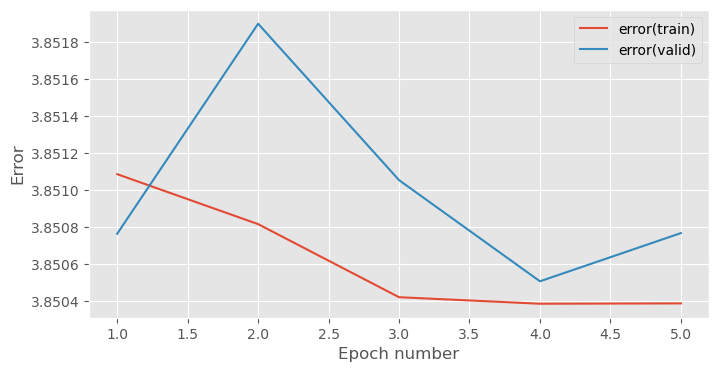

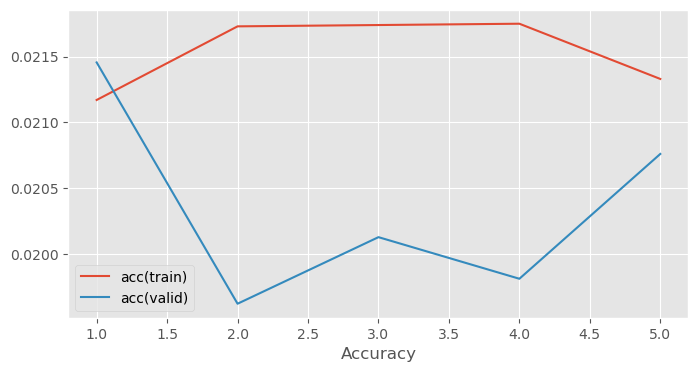

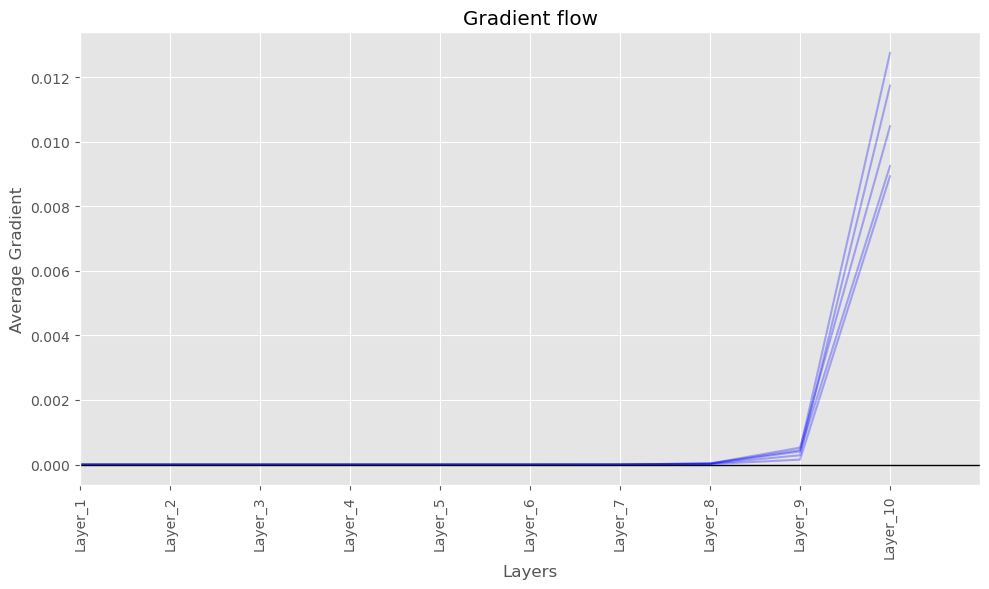

In [116]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1

def custom_activation_model():
    
    input_dim, output_dim, hidden_dim = 784, 47, 128
    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)


    # Create model with four hidden layer
    return MultipleLayerModel([
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
        CustomActivationLayer(), 
        AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
        CustomActivationLayer(),
        AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
        CustomActivationLayer(),
        AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
        CustomActivationLayer(),
        AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
    ])
    
model = custom_activation_model()

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
problematic_stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [117]:
problematic_stats = stats

In [120]:
# Save the gradient flow plot
grad_plot.savefig(os.path.join(FIGURE_PATH, f"custom_activation_grad_flow.png"), bbox_inches="tight")


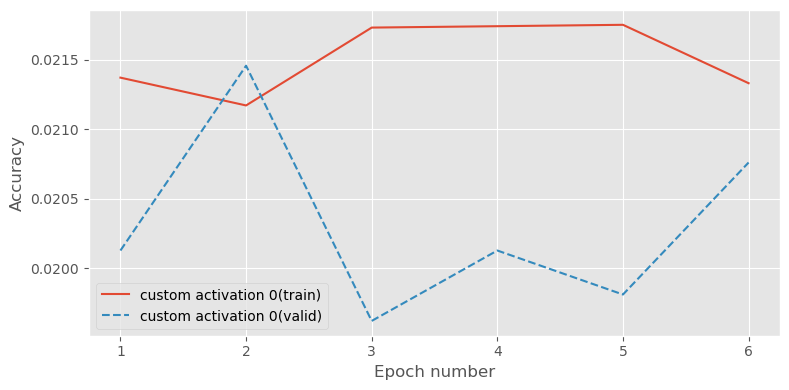

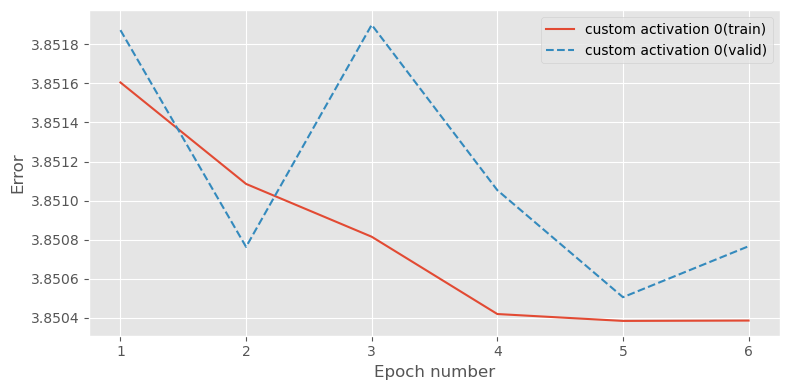

In [119]:
plot_width_accuracy_from_pack([(0, problematic_stats, keys)], save_path="custom_activation_curve", prefix="custom activation")

## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.